In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor



In [5]:
from xgboost import XGBRegressor

In [6]:
df = pd.read_csv('data/stud.csv')

In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
X = df.drop('math_score', axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [17]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [24]:
num_feature = X.select_dtypes(include='number').columns
cat_feature = X.select_dtypes(exclude='number').columns
print(num_feature)
print(cat_feature)



Index(['reading_score', 'writing_score'], dtype='str')
Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_feature),
        ("StandardScaler", numeric_transformer, num_feature),
    ]
)

In [26]:
X = preprocessor.fit_transform(X)

In [30]:
X.shape

(1000, 19)

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [34]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')





Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2692
- Mean Absolute Error: 4.2077
- R2 Score: 0.8752
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4967
- Mean Absolute Error: 4.3703
- R2 Score: 0.8755


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5393
- Mean Absolute Error: 5.1801
- R2 Score: 0.8077
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.8057
- Mean Absolute Error: 5.3547
- R2 Score: 0.8092


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2696
- Mean Absolute Error: 4.2073
- R2 Score: 0.8752
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.4951
- Mean Absolute Error: 4.3670
- R2 Score: 0.8756


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7089
- Mean Absolute Error: 4.5919
- R2 Score: 0.8535
-----------------------

In [39]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model Name", "R2_score"]).sort_values(by=["R2_score"], ascending=False)

,Model Name,R2_score
2,Ridge,0.875602
0,Linear Regression,0.875531
7,CatBoosting Regressor,0.858163
5,Random Forest Regressor,0.850682
8,AdaBoost Regressor,0.838389
6,XGBRegressor,0.825863
1,Lasso,0.809187
3,K-Neighbors Regressor,0.777423
4,Decision Tree,0.726708


In [40]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.55


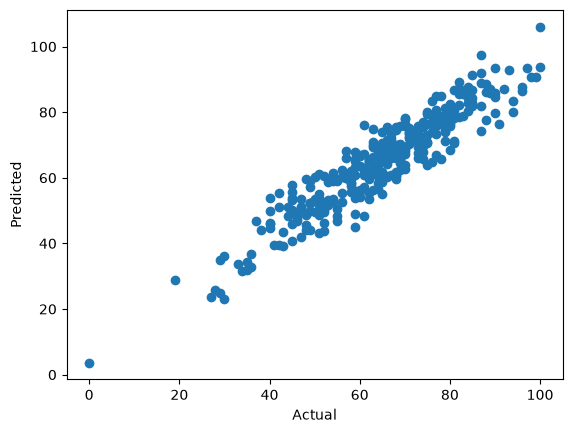

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

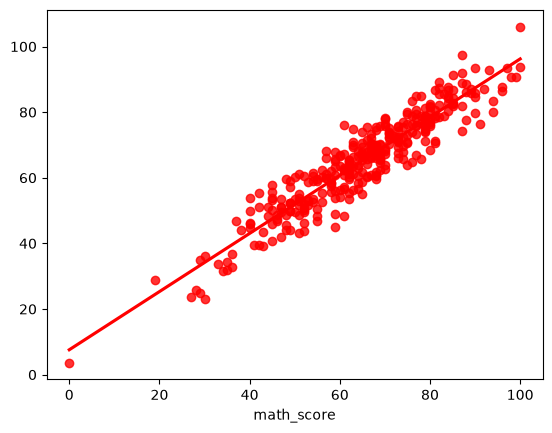

In [42]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [43]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.443742,14.556258
737,53,58.827765,-5.827765
740,80,76.885528,3.114472
660,74,76.890291,-2.890291
411,84,87.577625,-3.577625
...,...,...,...
506,68,74.555614,-6.555614
342,69,65.460049,3.539951
485,70,78.232278,-8.232278
711,80,79.987862,0.012138
